# MD 처방 파이프라인 — 단일추론 → 차분행렬 → 처방 → 검증·KPI (exp47 leak-free)

> 계획: `docs/eda_channel_prescription_plan.md` (Plan 2) · `docs/final_model_leakfree_switch_plan.md` (Plan 1)
> 모듈: `src/eval/md/{engine,tasks,prescription,validate}.py`

```
[Stage 1] 단일 추론 캐시        eng = MDEngine().run_single_inference()  →  prob·y·att24·Mass·장부(full/train)
    │                            (원칙 0: 전체 forward 1회. 이후 슬라이싱/조건부 집계)
    ▼
[Stage 2] 집계·차분 행렬        g1 = stage_g1_macro(eng)      성공망 vs 실패망 (A_diff±)
    │                            g2 = stage_g2_channel(eng)    POS 독점망 vs 인스타 독점망
    │                            cell_4a/4b/4c                  혼동행렬 구조 진단 (within-channel)
    ▼
[Stage 3] 처방 엔진 바인딩      pe = MDPrescriptionEngine(eng, g2)  →  get_md_prescription(seed)
    │                            §5: 장바구니·A빔·B anti·C 포화/신흥·E 견고성·F 소생
    ▼
[Stage 4] 검증·KPI 스코어보드   validate.run_all(eng, pe)     Tier1 순열·Tier2 holdout·Tier4 개입·Tier5 시너지·Precision@K
    │
    ▼
[Stage 5] 자동 저장             OUT_DIR/{inference_cache.npz, ledgers.parquet, engine_meta.json, scoreboard.json, figures/}
```
전역 객체 `eng·g1·g2·pe·scoreboard` 가 셀 간 메모리로 유기적으로 연결됩니다.

In [1]:
# --- Setup ---
import os, sys, json

def _find_repo_root(start):
    """cwd가 repo 어디에 있든(루트/notebooks 등) src/eval + experiments 가진 루트를 위로 탐색.
    VSCode·Jupyter는 보통 워크스페이스 루트에서 커널을 띄우므로 '../..' 고정 가정은 깨짐."""
    p = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(p, "src", "eval")) and os.path.isdir(os.path.join(p, "experiments")):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            return None
        p = parent

ROOT = _find_repo_root(os.getcwd())
assert ROOT, f"repo 루트를 못 찾음 (cwd={os.getcwd()}). 커널을 repo 폴더 안에서 재시작하세요."
if ROOT not in sys.path: sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False

from src.eval.md.engine import MDEngine, EngineConfig
from src.eval.md import tasks as T
from src.eval.md.prescription import MDPrescriptionEngine, get_md_prescription
from src.eval.md import validate as V
print("repo:", ROOT)

c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework


## 🔀 모델 선택 — exp47 vs v2_sweepA

| | exp47 (현 서빙) | v2_sweepA (검증 우세) |
|---|---|---|
| 구조 | HINGNN, copurchase 제거 | HINGNNv2(멀티태스크) + basket_comp 엣지 |
| 누수 | leak-free | leak-free |
| test PR-AUC | 0.570 | **0.606** |
| test 운영점 F1 | 0.544 | **0.583** |
| 과적합 gap | 0.215 | **0.135** |

`MODEL` 한 줄만 바꿔 두 모델 중 선택. 출력은 모델별 폴더로 분리 저장됩니다.

In [2]:
# ── 모델 선택 (여기만 바꾸면 됨) ──
MODEL = "v2_sweepA"      # "v2_sweepA"(최종 채택)  또는  "exp47"

ENGINE_CFG = EngineConfig.exp47() if MODEL == "exp47" else EngineConfig.v2_sweepA()
OUT_DIR = f"experiments/results/md_prescription/{MODEL}"
FIG_DIR = os.path.join(OUT_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)
print(f"선택 모델: {MODEL}  | exp_dir={ENGINE_CFG.exp_dir}  | THR={ENGINE_CFG.thr}  | out={OUT_DIR}")

선택 모델: v2_sweepA  | exp_dir=experiments/results/v2_sweepA  | THR=0.7757  | out=experiments/results/md_prescription/v2_sweepA


## Stage 1 — 단일 추론 캐시 (원칙 0: 전체 forward 1회)

In [3]:
eng = MDEngine(ENGINE_CFG).run_single_inference()
eng.build_mass()
lg_full  = eng.build_ledger("full")
lg_train = eng.build_ledger("train")
c = eng.cache
print(f"[{MODEL}] is_v2={getattr(eng,'is_v2',False)}  | P/K/I = {c['P']}/{c['K']}/{c['I']}  | base={c['base_rate']:.3f}  | THR={eng.cfg.thr}")
print(f"att 관계 {len(c['att'])}종 | prob 평균 {c['prob'].mean():.3f}")
print(f"장부(full)  killer={len(lg_full.killer)} mine={len(lg_full.mine)} hub={len(lg_full.hub)}")
print(f"장부(train) killer={len(lg_train.killer)} mine={len(lg_train.mine)} hub={len(lg_train.hub)}")

[v2_sweepA] is_v2=True  | P/K/I = 5033/2063/335  | base=0.238  | THR=0.7757
att 관계 22종 | prob 평균 0.381
장부(full)  killer=62 mine=131 hub=144
장부(train) killer=57 mine=122 hub=120


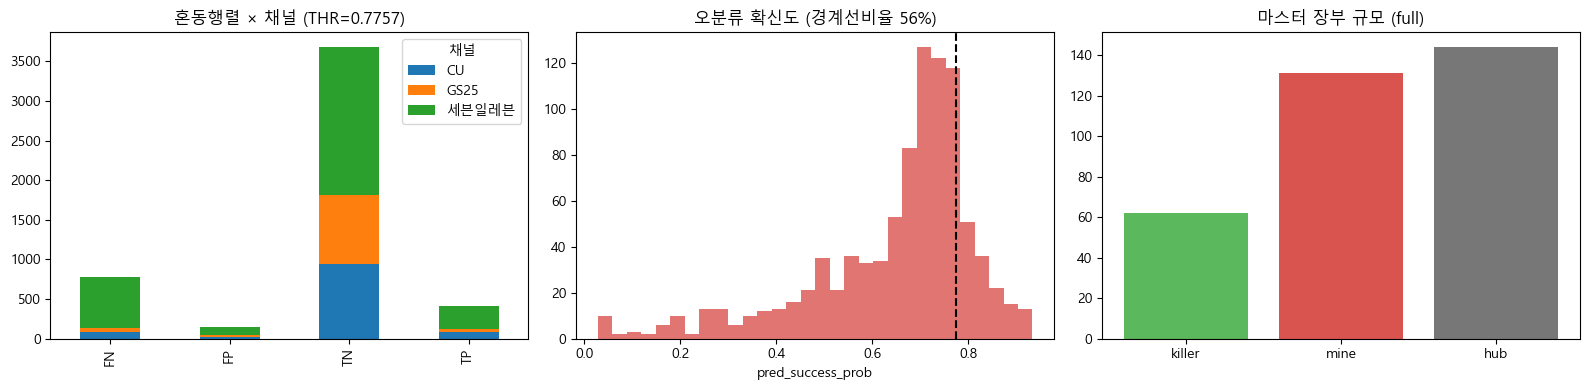

In [4]:
# Stage 1 대시보드: 혼동행렬 × 채널 + 오분류 확신도 + 장부 규모
diag = T.cell_4a(eng)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ct = diag["crosstab"].drop(index="All", errors="ignore").drop(columns="All", errors="ignore")
ct.plot(kind="bar", stacked=True, ax=ax[0]); ax[0].set_title(f"혼동행렬 × 채널 (THR={eng.cfg.thr})"); ax[0].set_xlabel("")
ax[1].hist(diag["prob_err"], bins=30, color="#d9534f", alpha=.8); ax[1].axvline(eng.cfg.thr, ls="--", c="k")
ax[1].set_title(f"오분류 확신도 (경계선비율 {diag['borderline_frac']:.0%})"); ax[1].set_xlabel("pred_success_prob")
ax[2].bar(["killer","mine","hub"], [len(lg_full.killer),len(lg_full.mine),len(lg_full.hub)], color=["#5cb85c","#d9534f","#777"])
ax[2].set_title("마스터 장부 규모 (full)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,"stage1_dashboard.png"), dpi=110, bbox_inches="tight"); plt.show()

## Stage 2 — 집계·차분 행렬 (거시 G-1 / 미시 G-2) + 혼동행렬 구조 진단

In [5]:
g1   = T.stage_g1_macro(eng)                 # 성공망 vs 실패망
g2   = T.stage_g2_channel(eng, "track1")     # 전 채널 POS vs 인스타 (처방 주 신호원)
g2b  = T.stage_g2_channel(eng, "track2")     # 세븐 한정 검증 트랙
print("G-1 A_diff+ nnz:", int((g1.A_diff_plus>0).sum()), "| A_diff- nnz:", int((g1.A_diff_minus>0).sum()))
print("G-2(track1) POS독점망 nnz:", int((g2.A_diff_pos>0).sum()), "| 인스타독점망 nnz:", int((g2.A_diff_insta>0).sum()))

G-1 A_diff+ nnz: 31852 | A_diff- nnz: 52747
G-2(track1) POS독점망 nnz: 27112 | 인스타독점망 nnz: 7612


In [6]:
# Cell 4b — 분면별 1-hop 위상 대조 (within-channel)
display(T.cell_4b(eng, within_channel=True))
# Cell 4c — 극단 오분류 Top
ext = T.cell_4c(eng, top_k=8)
print("── 가장 억울한 FN (저prob 성공) ──"); display(ext["FN"])
print("── 가장 황당한 FP (고prob 실패) ──"); display(ext["FP"])

degree  hubness  ip_count  killer_ratio  mine_ratio
channel quad                                                     
CU      FN    27.389    0.487     0.311         0.047       0.043
        FP    24.542    1.795     0.958         0.014       0.022
        TN    22.770    0.241     0.185         0.025       0.078
        TP    28.659    1.232     1.012         0.054       0.033
GS25    FN    32.233    0.486     0.837         0.036       0.069
        FP    22.667    1.382     0.500         0.004       0.037
        TN    22.860    0.222     0.374         0.026       0.087
        TP    30.222    1.288     1.472         0.063       0.026
세븐일레븐   FN    23.431    0.417     0.063         0.037       0.055
        FP    31.457    1.189     0.495         0.047       0.027
        TN    20.019    0.094     0.086         0.020       0.107
        TP    29.405    1.111     0.599         0.063       0.029

── 가장 억울한 FN (저prob 성공) ──


,product,channel,prob,neighbors
0,훼밀리)복숭아무케루푸루푸루구미40g,세븐일레븐,0.029,"복숭아[m], 젤리[h], 간식[h]"
1,젼언니과일모양프룻팝스,GS25,0.031,"과즙[n], 포도[m], 망고[h], 복숭아[m], 과일[n], 딸기[h], 디저트..."
2,NCTDREAMXGS25아이돌컴백샌드위치,GS25,0.032,"NCT[n], 아이돌[n], 샌드위치[k], 샌드[n], 빵[h]"
3,훼밀리)사과무케루푸루푸루구미40g,세븐일레븐,0.033,"무[n], 사과[h], 과일[n], 젤리[h]"
4,요아정요거트초코쉘팝팝콘딸,GS25,0.035,"쉘[n], CJ[n], 농심[n], 팝콘[h], 롯데[h], 요거트[n], 딸기[h..."
5,PB)요구르트280ml,세븐일레븐,0.043,"유산균[n], 요거트[n], 간식[h]"
6,빵빵이의얼큰포장마차어묵국수,CU,0.045,"포장마차[n], 얼큰함[m], 국수[n], 어묵[h], 시원[m], 매콤[k]"
7,제스)모리나가밀크카라멜모나카97g,세븐일레븐,0.046,"모나카[n], 일본[n], 밀크[n], 카라멜[h], 디저트[h], 간식[h]"


── 가장 황당한 FP (고prob 실패) ──


,product,channel,prob,neighbors
0,야끼소바도그,CU,0.934,"야끼소바[h], 가쓰오부시[n], 핫도그[h], 마요[n], 콜라[n], 짭조름함[..."
1,TXT별모아쿠키,CU,0.930,"쿠키[h], 시즌[n], 과자[h], 고소[h]"
2,KBO돌직구딸기비스킷,CU,0.930,"비스킷[n], 담백[n], 새콤[h], 딸기[h], 과자[h], 바삭[n], 달콤[..."
3,설레임말차,GS25,0.929,"설레임[n], 쌉싸름함[n], 롯데[h], 말차[n], 음료[n], 달콤[h], 간..."
4,맛제일)스팸아라비아따파스타,세븐일레븐,0.927,"아라비아따[n], CJ[n], 스팸[n], 파스타[n], 콜라보[n], 콜라[n],..."
5,소세지피자빵초코케이크,GS25,0.924,"피자[h], 소시지[n], 케이크[h], 치즈[h], 빵[h], 초코[h]"
6,크림치즈구름빵,GS25,0.922,"구름[n], 치즈[h], 빵[h], 크림[h]"
7,베이스볼크림초코,GS25,0.920,"녹진함[n], 촉촉[h], 과자[h], 바삭[n], 크림[h], 초코[h], 디저트..."


## Stage 3 — 처방 엔진 바인딩 (§5: 장바구니·A~F)

In [7]:
pe = MDPrescriptionEngine(eng, g2, universe="full")
for seed in ["마라","로제","단백질","흑임자","위스키"]:
    print("="*70); print(get_md_prescription(pe, seed))

MD님께서 활용하실 '마라' 키워드는 성공 특이망 분석 결과 [기획 반려] 대상입니다. (포화도: 레드오션(포화·자기잠식 위험) · 근거 신뢰도: 높음/지지도 63)
· 함께 조합할 [도쿠시마, 짜파게티, 마파, 두부] 속성은 POS 매출 독점망 기반 → 제품 속성으로 내실화하십시오.
   ↳ K-P-K 경유 제품: 도쿠시마←도쿠시마라면큰컵 · 짜파게티←마라짜파게티큰사발 · 마파←마라마파두부덮밥380g · 두부←마라마파두부덮밥380g
· [정통, 탕, 국물, 쫄깃함] 속성은 인스타 반응 독점망 기반 → 초기 마케팅 카피로 활용하십시오.
   ↳ K-P-K 경유 제품: 정통←정통마라탕면 · 탕←정통마라탕면 · 국물←정통마라탕면 · 쫄깃함←정통마라탕면
· ⚠ 피해야 할 조합(점수 하락): [중식, 깊은맛, 두부, 피].
· 🛒 장바구니 보완재(번들 제안): 위스트)마라곤약 향라맛(383.86), 오뚜기)고단백컵누들매콤로제(146.7), 농심)누들핏마라탄탄(31.49).
· 💉 서브넷 내 강화/대체(시너지 상위): [순대, 견과류, 탕, 폭탄].
MD님께서 활용하실 '로제' 키워드는 성공 특이망 분석 결과 [중립] 대상입니다. (포화도: 레드오션(포화·자기잠식 위험) · 근거 신뢰도: 높음/지지도 23)
· 함께 조합할 [늘어남, 마카로니, 파마산, 당면] 속성은 POS 매출 독점망 기반 → 제품 속성으로 내실화하십시오.
   ↳ K-P-K 경유 제품: 늘어남←로제햄마카로니콘치즈25… · 마카로니←로제햄마카로니콘치즈25… · 파마산←미정당스팸로제납작당면3… · 당면←미정당스팸로제납작당면3…
· [분식, 꾸덕함, 불닭, 떡볶이] 속성은 인스타 반응 독점망 기반 → 초기 마케팅 카피로 활용하십시오.
   ↳ K-P-K 경유 제품: 분식←로제떡볶이 · 꾸덕함←로제불닭볶음면 · 불닭←로제불닭볶음면 · 떡볶이←로제떡볶이
· ⚠ 피해야 할 조합(점수 하락): [떡볶이, 고단백, 파마산, 토핑].
· 🛒 장바구니 보완재(번들 제안): 앙리마티스)하트와인볼(로제)500ml캔(17

## Stage 3.5 — 조합 설명 (유형 × 인과 교차)

`explain_keyword`: 키워드의 **메타패스+1hop 이웃을 자동탐색** → 각 이웃을 **prob 시너지/잠식**(Layer1, 인과)으로 판정 → **사전정의 4유형**(Layer2: killer 성공특이 / mine 지뢰 / hub 백본 / neutral 보조)과 교차해 *왜* 그런지 설명.

- **유형 소스 = 핫스왑**: 지금은 초안 `keyword_final.csv`(dummy). 확정되면 같은 경로 재생성만으로 갈아끼워짐 (`KeywordTypeSource`).
- **불일치 칸이 인사이트**: killer인데 시너지≤0 = *상관만/후광* / mine인데 시너지>0 = *의외의 구원*.

In [8]:
from src.eval.md.explain import explain_keyword
from src.eval.md.keyword_types import KeywordTypeSource

# 유형 소스(4분류): 초안 keyword_final.csv = dummy. 확정 시 같은 경로 재생성만으로 스왑.
#   없으면 자동장부(build_ledger) fallback. 임의 정의는 KeywordTypeSource.from_mapping({이름:tag}).
ktypes = KeywordTypeSource.default(eng)
print("유형 소스:", ktypes.source)

# Layer1(prob 시너지/잠식) × Layer2(4유형) 교차 설명 — 메타패스+1hop 이웃 자동탐색
for seed in ["고창", "마라", "흑임자"]:
    r = explain_keyword(eng, seed, types=ktypes, n_headroom=10, max_neighbors=10)
    print("=" * 70)
    print(r.get("text") or r.get("error"))

# 마지막 시드 상세표 (synergy 내림차순 · 유형↔인과 교차)
display(r["table"][["이웃", "유형", "역할", "synergy", "margin_alone", "margin_given", "설명"]])

유형 소스: csv:data/processed/hin/keyword_final.csv(2063)
[고창] (유형: 성공 특이(잘 붙는))  —  유형소스=csv:data/processed/hin/keyword_final.csv(2063)
· 보완(시너지) 이웃:
   + 빈츠(성공 특이(잘 붙는)) Δ+0.016 → 진짜 유발 — 성공 특이 속성이 인과적으로도 성공확률↑
   + 한정(성공 특이(잘 붙는)) Δ+0.014 → 진짜 유발 — 성공 특이 속성이 인과적으로도 성공확률↑
   + 촉촉(일반 백본) Δ+0.012 → 백본 보강 — 일반 속성이 약하게 받쳐줌
   + 말차(보조(무색무취)) Δ+0.007 → 보조 — 약한 + 효과
   + 고소(일반 백본) Δ+0.002 → 백본 보강 — 일반 속성이 약하게 받쳐줌
· 잠식(카니발) 이웃:
   − 간식(일반 백본) Δ-0.000 → 희석 — 무색무취가 메시지를 흐림
   − 고구마(일반 백본) Δ-0.000 → 희석 — 무색무취가 메시지를 흐림
   − 과자(일반 백본) Δ-0.005 → 희석 — 무색무취가 메시지를 흐림
   − 디저트(일반 백본) Δ-0.017 → 희석 — 무색무취가 메시지를 흐림
   − 모찌(성공 특이(잘 붙는)) Δ-0.020 → 상관만/후광 — 성공제품에 붙어있을 뿐, 이 조합선 오히려 끌어내림
· ⚠ 유형↔인과 불일치(주목):
   ! 모찌(성공 특이(잘 붙는)) 잠식(카니발) → 상관만/후광 — 성공제품에 붙어있을 뿐, 이 조합선 오히려 끌어내림
[마라] (유형: 실패 특이(지뢰))  —  유형소스=csv:data/processed/hin/keyword_final.csv(2063)
· 보완(시너지) 이웃:
   + 탕(실패 특이(지뢰)) Δ+0.017 → 의외의 구원 — 실패 특이(지뢰)인데 이 조합에선 살림
   + 동파육(실패 특이(지뢰)) Δ+0.010 → 의외의 구원 — 실패 특이(지뢰)인데 이 조합에선 살림
   + 딤섬(보조(무색무취)) Δ+0.009 → 보조 —

,이웃,유형,역할,synergy,margin_alone,margin_given,설명
0,견과류,보조(무색무취),보완(시너지),0.0217,-0.0358,-0.0140,보조 — 약한 + 효과
1,입자감,실패 특이(지뢰),보완(시너지),0.0162,-0.0215,-0.0053,의외의 구원 — 실패 특이(지뢰)인데 이 조합에선 살림
2,바삭,보조(무색무취),중립,0.0001,0.0092,0.0092,보조 — 인과 효과 거의 없음
3,시즌,보조(무색무취),잠식(카니발),-0.0132,0.0328,0.0195,보조 — 약한 − 효과
4,케이크,일반 백본,잠식(카니발),-0.0168,0.0391,0.0222,희석 — 무색무취가 메시지를 흐림
5,묵직함,보조(무색무취),잠식(카니발),-0.0190,0.0439,0.0248,보조 — 약한 − 효과
6,샐러드,실패 특이(지뢰),잠식(카니발),-0.0219,0.0492,0.0272,예상된 잠식 — 실패 특이 속성이 성공확률을 끌어내림
7,촉촉,일반 백본,잠식(카니발),-0.0343,0.0722,0.0379,희석 — 무색무취가 메시지를 흐림
8,한정,성공 특이(잘 붙는),잠식(카니발),-0.0419,0.0889,0.0471,"상관만/후광 — 성공제품에 붙어있을 뿐, 이 조합선 오히려 끌어내림"
9,저당,보조(무색무취),잠식(카니발),-0.0441,0.0913,0.0472,보조 — 약한 − 효과


## Stage 4 — 실시간 검증 · KPI 스코어보드 (Tier1·2·4·5 + Precision@K)

In [9]:
scoreboard = V.run_all(eng, pe, light=True)   # light=False면 순열 500회·표본 확대
rows = []
def _row(name, val, passed, note):
    rows.append(dict(검증=name, 값=val, 통과=("✅" if passed else "⚠️"), 비고=note))
t1=scoreboard["tier1_permutation"]; _row("Tier1 순열귀무", f"{t1['pass_rate']:.0%}", t1['pass_rate']>=0.7, f"killer {t1['n_killer']}개 중 95pct 초과")
t2=scoreboard["tier2_holdout"];    _row("Tier2 holdout", f"PRAUC {t2['test_prauc']} / base {t2['base']}", t2['passed'], f"CI_lo {t2['ci_lo']}")
t4=scoreboard["tier4_intervention"];_row("Tier4 개입(faithful)", f"killer {t4['killer_pos_rate']} vs rand {t4['random_pos_rate']}", t4['passed'], f"mine 비상승 {t4['mine_nonpos_rate']}")
t5=scoreboard["tier5_synergy"];    _row("Tier5 조합시너지", f"초가법 {t5['superadd_rate']}", t5['superadd_rate']>0.0, f"n={t5['n']}")
bk=scoreboard["backtest_precision_at_k"]; _row("KPI Precision@K", f"P@k {bk['precision_at_k']} / hit {bk['hit_rate']}", bk['precision_at_k']>0.0, f"n={bk['n']} (랜덤≈0.5%)")
board = pd.DataFrame(rows); display(board)

c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


,검증,값,통과,비고
0,Tier1 순열귀무,84%,✅,killer 62개 중 95pct 초과
1,Tier2 holdout,PRAUC 0.2861 / base 0.2387,✅,CI_lo 0.2422
2,Tier4 개입(faithful),killer 0.7 vs rand 0.3,✅,mine 비상승 0.7
3,Tier5 조합시너지,초가법 0.0,⚠️,n=10
4,KPI Precision@K,P@k 0.0725 / hit 0.275,✅,n=40 (랜덤≈0.5%)


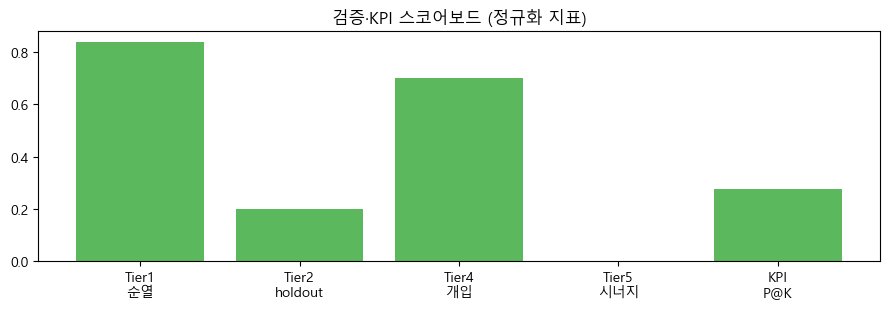

In [10]:
# KPI 스코어보드 시각화
fig, ax = plt.subplots(figsize=(9,3.2))
labels=["Tier1\n순열","Tier2\nholdout","Tier4\n개입","Tier5\n시너지","KPI\nP@K"]
vals=[t1['pass_rate'], t2['test_prauc']/max(t2['base'],1e-9)-1, t4['killer_pos_rate'], t5['superadd_rate'], bk['hit_rate']]
cols=["#5cb85c" if p else "#f0ad4e" for p in [t1['pass_rate']>=0.7,t2['passed'],t4['passed'],t5['superadd_rate']>0,bk['precision_at_k']>0]]
ax.bar(labels, vals, color=cols); ax.set_title("검증·KPI 스코어보드 (정규화 지표)"); ax.axhline(0, c="k", lw=.5)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,"stage4_scoreboard.png"), dpi=110, bbox_inches="tight"); plt.show()

## Stage 5 — 제안 파일 구조로 자동 저장

In [11]:
# 캐시·장부·메타 저장 (engine.save_cache) + 스코어보드 + 처방 샘플 + 그림
eng.save_cache(OUT_DIR)
with open(os.path.join(OUT_DIR,"scoreboard.json"),"w",encoding="utf-8") as f:
    json.dump(scoreboard, f, ensure_ascii=False, indent=2, default=lambda o: o.tolist() if hasattr(o,'tolist') else str(o))
with open(os.path.join(OUT_DIR,"prescriptions_sample.txt"),"w",encoding="utf-8") as f:
    for seed in ["마라","로제","단백질","흑임자","위스키"]:
        f.write("="*70+"\n"+get_md_prescription(pe, seed)+"\n")
board.to_csv(os.path.join(OUT_DIR,"scoreboard.csv"), index=False, encoding="utf-8-sig")

print("저장 완료 →", OUT_DIR)
for root,_,files in os.walk(OUT_DIR):
    for fn in sorted(files):
        p=os.path.join(root,fn); print(f"  {os.path.relpath(p,OUT_DIR):40s} {os.path.getsize(p):>10,} B")

저장 완료 → experiments/results/md_prescription/v2_sweepA
  engine_meta.json                                337 B
  inference_cache.npz                          44,783 B
  ledgers.parquet                              31,570 B
  prescriptions_sample.txt                      6,104 B
  scoreboard.csv                                  330 B
  scoreboard.json                               1,199 B
  figures\stage1_dashboard.png                 36,945 B
  figures\stage4_scoreboard.png                13,699 B
